In [1]:
# 数据预处理通用导入
import os
import re
import time
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import requests
import fits
from concurrent.futures import ThreadPoolExecutor, as_completed

d:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# 天文数据与预处理相关导入
import warnings
import scipy
from scipy import signal
from scipy.interpolate import splev, splrep

import astropy.io.fits as afits
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.labelsize': 'x-large'})

# Data processing

In [3]:
# full preprocessing pipeline: integrate file loading + labeling + loading + uid dedup + anomaly filter
import importlib
import spectra_io as _sio
importlib.reload(_sio)

# Choose available pipeline entrypoint
if hasattr(_sio, 'run_screening_preprocess_from_files'):
    run_pipeline_from_files = _sio.run_screening_preprocess_from_files
    _use_file_wrapper = True
elif hasattr(_sio, 'run_screening_preprocess_pipeline'):
    run_screening_preprocess_pipeline = _sio.run_screening_preprocess_pipeline
    _use_file_wrapper = False
else:
    raise ImportError(
        'spectra_io 中未找到可用的预处理管线函数。'
    )

# export function
if hasattr(_sio, 'export_spectra_csv'):
    export_spectra_csv = _sio.export_spectra_csv
elif hasattr(_sio, 'export_datacube_csv'):
    export_spectra_csv = _sio.export_datacube_csv
else:
    raise ImportError(
        'spectra_io 中未找到 export_spectra_csv。'
    )

common_wave = np.arange(3800.0, 4500.0, 1.0)

if _use_file_wrapper:
    # New integrated path: no external stars_df required
    pipe = run_pipeline_from_files(
        stars_csv='stars.csv',
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )
else:
    # Backward compatible fallback
    if 'stars_df' not in globals():
        stars_df = pd.read_csv('stars.csv')
    pipe = run_screening_preprocess_pipeline(
        stars_df=stars_df,
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )

X_clean = pipe['datacube_clean']
stars_clean = pipe['stars_clean']
stars_df = pipe.get('stars_stage_dropna_labeled', stars_clean.copy())

print('summary:', pipe['summary'])
print('label_report:', pipe['label_report'])
print('dedup_report:', pipe['dedup_report'])
print('anomaly_report:', pipe['anomaly_report'])
print('X_clean shape:', X_clean.shape, 'stars_clean shape:', stars_clean.shape)

# Optional export for cross-notebook use (disabled by default)
# meta_cols = [c for c in ['ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'uid', 'filepath', 'label'] if c in stars_clean.columns]
# out_csv = 'spectra_clean_wide.csv'
# export_spectra_csv(
#     datacube=X_clean,
#     common_wave=common_wave,
#     out_csv=out_csv,
#     metadata_df=stars_clean[meta_cols],
#     flux_prefix='flux_',
#     wave_digits=1,
# )
# print('exported:', out_csv)

# if len(pipe.get('load_drop_log', [])) > 0:
#     display(pipe['load_drop_log'].head())

  0%|          | 0/48440 [00:00<?, ?it/s]

summary: {'n_input': 48440, 'n_after_dropna': 48440, 'n_positive_labeled': 107, 'n_loaded': 37182, 'n_normalized_ok': 37182, 'n_after_uid_dedup': 34204, 'n_after_anomaly_filter': 33589}
label_report: {'n_catalog_rows': 148, 'n_match_unique': 107, 'n_positive': 107, 'n_unlabeled': 48333, 'tolerance_arcsec': 1.0}
dedup_report: {'n_before': 37182, 'n_after': 34204, 'n_removed': 2978, 'uid_col': 'uid', 'snr_col': 'snru'}
anomaly_report: {'n_before': 34204, 'n_after': 33589, 'n_removed': 615, 'median_low': 1.0172393333911895, 'median_high': 1.0697653943300247, 'mad_low': 0.038511829376220705, 'mad_high': 0.11002329126000406}
X_clean shape: (33589, 700) stars_clean shape: (33589, 17)


# KNN 聚类

In [4]:
# KNN + 分子带掩盖聚类约束（可解释中心向量构建）
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

knn_param_cols = ['teff', 'logg', 'feh']
knn_param_cols = [c for c in knn_param_cols if c in stars_clean.columns]
if len(knn_param_cols) < 3:
    raise RuntimeError(f'可用于KNN中心向量的列不足，当前仅有: {knn_param_cols}')

param_df = stars_clean[knn_param_cols].apply(pd.to_numeric, errors='coerce')
param_df = param_df.fillna(param_df.median(numeric_only=True))

scaler = StandardScaler()
X_params_scaled = scaler.fit_transform(param_df.values)

if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，请先执行光谱预处理单元。')
if len(X_clean) != len(stars_clean):
    raise RuntimeError('X_clean 与 stars_clean 行数不一致，无法构建掩盖聚类。')

masked_cube = np.asarray(X_clean, dtype=float).copy()
for l1, l2 in [(3830, 3883), (4120, 4216), (4285, 4315)]:
    m = (common_wave >= l1) & (common_wave <= l2)
    fill_vals = np.nanmedian(masked_cube[:, ~m], axis=1)
    fill_vals = np.where(np.isfinite(fill_vals), fill_vals, 1.0)
    masked_cube[:, m] = fill_vals[:, None]

n_samples = masked_cube.shape[0]
n_components_masked = int(min(25, masked_cube.shape[1], max(2, n_samples - 1)))
X_masked_emb = PCA(n_components=n_components_masked, random_state=42).fit_transform(masked_cube)

n_clusters_masked = int(np.clip(np.sqrt(n_samples) / 2, 10, 45))
kmeans_masked = KMeans(n_clusters=n_clusters_masked, random_state=42, n_init=20)
masked_labels = kmeans_masked.fit_predict(X_masked_emb)
stars_clean['masked_cluster_id'] = masked_labels

K = 180
global_knn = NearestNeighbors(n_neighbors=min(K + 1, len(stars_clean)), metric='euclidean', algorithm='auto')
global_knn.fit(X_params_scaled)
global_distances, global_indices = global_knn.kneighbors(X_params_scaled)

neighbor_indices_all = []
neighbor_distances_all = []
for i in range(len(stars_clean)):
    cid = masked_labels[i]
    local_idx = np.where(masked_labels == cid)[0]

    if len(local_idx) >= 3:
        local_X = X_params_scaled[local_idx]
        local_k = min(K + 1, len(local_idx))
        local_knn = NearestNeighbors(n_neighbors=local_k, metric='euclidean', algorithm='auto')
        local_knn.fit(local_X)
        local_pos = int(np.where(local_idx == i)[0][0])
        d_loc, idx_loc = local_knn.kneighbors(local_X[local_pos].reshape(1, -1))
        nb_local = local_idx[idx_loc[0]]
        dd_local = d_loc[0]
        keep = nb_local != i
        nb = nb_local[keep].tolist()
        dd = dd_local[keep].tolist()
    else:
        nb, dd = [], []

    if len(nb) < K:
        g_nb = global_indices[i, 1:].tolist()
        g_dd = global_distances[i, 1:].tolist()
        for j, d in zip(g_nb, g_dd):
            if j not in nb:
                nb.append(int(j))
                dd.append(float(d))
            if len(nb) >= K:
                break

    neighbor_indices_all.append(np.asarray(nb[:K], dtype=int))
    neighbor_distances_all.append(np.asarray(dd[:K], dtype=float))

stars_clean['neighbor_indices'] = neighbor_indices_all
stars_clean['neighbor_distances'] = neighbor_distances_all

center_scaled = np.zeros_like(X_params_scaled, dtype=float)
center_euclid = np.full(len(stars_clean), np.nan, dtype=float)
for i, nb in enumerate(stars_clean['neighbor_indices']):
    nb = np.asarray(nb, dtype=int)
    if nb.size == 0:
        continue
    local_center = X_params_scaled[nb].mean(axis=0)
    center_scaled[i] = local_center
    center_euclid[i] = np.linalg.norm(X_params_scaled[i] - local_center)

center_orig = scaler.inverse_transform(center_scaled)
for j, col in enumerate(knn_param_cols):
    stars_clean[f'knn_center_{col}'] = center_orig[:, j]

stars_clean['knn_center_euclid'] = center_euclid

dist_rank = pd.Series(center_euclid).rank(pct=True, method='average')
stars_clean['knn_euclid_prob'] = dist_rank.clip(0.0, 1.0).values

dist_med = np.nanmedian(center_euclid)
dist_mad = np.nanmedian(np.abs(center_euclid - dist_med)) + 1e-12
stars_clean['knn_center_dist_z'] = (center_euclid - dist_med) / (1.4826 * dist_mad)

print(f'KNN features: {knn_param_cols}, K={K}, masked_clusters={n_clusters_masked}')


KNN features: ['teff', 'logg', 'feh'], K=180, masked_clusters=45


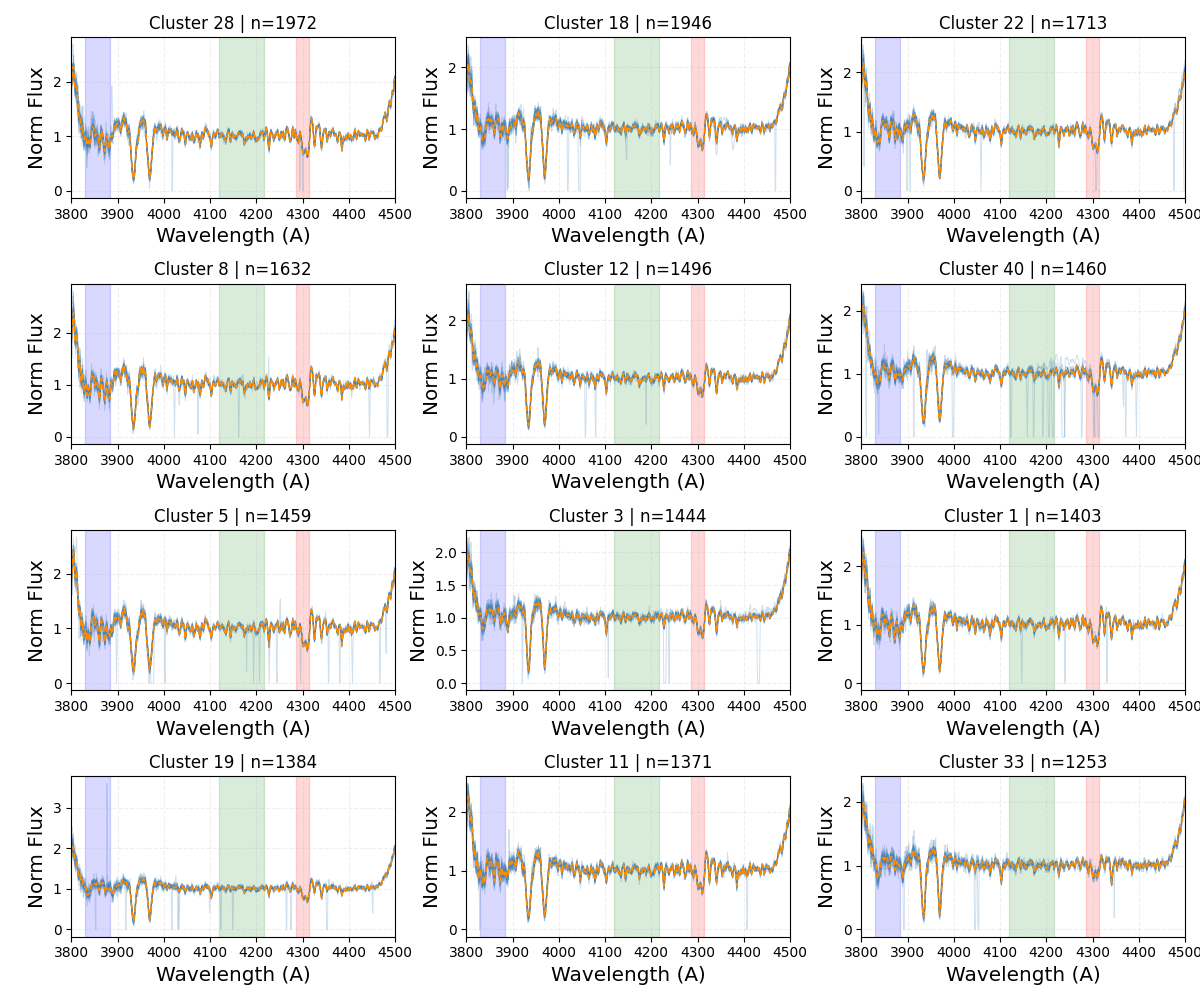

In [5]:
# 分子带掩盖聚类可视化
if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id，请先运行 KNN + 掩盖聚类单元。')
if 'X_clean' not in globals() or len(X_clean) != len(stars_clean):
    raise RuntimeError('缺少 X_clean 或行数不一致，无法可视化聚类光谱。')

n_groups = 12
n_spectra_per_group = 20
np.random.seed(42)

cluster_counts = stars_clean['masked_cluster_id'].value_counts().sort_values(ascending=False)
selected_clusters = cluster_counts.head(min(n_groups, len(cluster_counts))).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(12, 10))
axes = axes.flatten()

for ax_idx, cid in enumerate(selected_clusters):
    ax = axes[ax_idx]
    idxs = np.where(stars_clean['masked_cluster_id'].values == cid)[0]

    if len(idxs) > n_spectra_per_group:
        idxs_plot = np.random.choice(idxs, size=n_spectra_per_group, replace=False)
    else:
        idxs_plot = idxs

    ax.axvspan(3830, 3883, alpha=0.15, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.15, color='green', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.15, color='red', zorder=0)

    for idx in idxs_plot:
        ax.plot(common_wave, X_clean[idx], color='steelblue', alpha=0.25, linewidth=0.7, zorder=1)

    mean_flux = np.nanmean(X_clean[idxs], axis=0)
    ax.plot(common_wave, mean_flux, color='darkorange', linewidth=1.2, linestyle='--', zorder=2)

    ax.set_title(f'Cluster {cid} | n={len(idxs)}')
    ax.set_xlim(3800, 4500)
    ax.set_xlabel('Wavelength (A)')
    ax.set_ylabel('Norm Flux')
    ax.grid(alpha=0.2, linestyle='--')

for j in range(len(selected_clusters), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# CN CH index

In [6]:
# 基础特征表
base_cols = [
    'teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g',
    'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z',
    'knn_center_teff', 'knn_center_logg', 'knn_center_feh', 'knn_center_mag_ps_g', 'knn_center_snru'
]
base_cols = [c for c in base_cols if c in stars_clean.columns]

feature_df = stars_clean[base_cols].copy()
print(feature_df.columns.tolist())

['teff', 'logg', 'feh', 'label', 'snru', 'mag_ps_g', 'knn_center_euclid', 'knn_euclid_prob', 'knn_center_dist_z', 'knn_center_teff', 'knn_center_logg', 'knn_center_feh']


In [7]:
#  计算 CN/CH 指数 
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return np.mean(x)

def compute_band_index(wave, flux, band, blue, red):
    """
    指数定义:
    index = -2.5 * log10(F_band / F_cont)

    band: 吸收带窗口 (lam1, lam2)
    blue, red: 两侧连续谱窗口
    """
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    band_mask = (wave >= band[0]) & (wave <= band[1])
    blue_mask = (wave >= blue[0]) & (wave <= blue[1])
    red_mask  = (wave >= red[0])  & (wave <= red[1])

    F_band = safe_mean(flux[band_mask])
    F_blue = safe_mean(flux[blue_mask])
    F_red  = safe_mean(flux[red_mask])

    if not np.isfinite(F_band) or not np.isfinite(F_blue) or not np.isfinite(F_red):
        return np.nan

    F_cont = 0.5 * (F_blue + F_red)

    if F_band <= 0 or F_cont <= 0:
        return np.nan

    return -2.5 * np.log10(F_band / F_cont)

band_defs = {
    'CN3839': {
        'band': (3830, 3883),
        'blue': (3894, 3910),
        'red':  (4000, 4020)
    },
    'CN4142': {
        'band': (4120, 4216),
        'blue': (4055, 4080),
        'red':  (4240, 4280)
    },
    'CH4300': {
        'band': (4285, 4315),
        'blue': (4240, 4280),
        'red':  (4390, 4460)
    }
}


cn3839_list = []
cn4142_list = []
ch4300_list = []

for i in range(len(X_clean)):
    flux = X_clean[i]

    cn3839 = compute_band_index(
        common_wave, flux,
        band_defs['CN3839']['band'],
        band_defs['CN3839']['blue'],
        band_defs['CN3839']['red']
    )
    cn4142 = compute_band_index(
        common_wave, flux,
        band_defs['CN4142']['band'],
        band_defs['CN4142']['blue'],
        band_defs['CN4142']['red']
    )
    ch4300 = compute_band_index(
        common_wave, flux,
        band_defs['CH4300']['band'],
        band_defs['CH4300']['blue'],
        band_defs['CH4300']['red']
    )

    cn3839_list.append(cn3839)
    cn4142_list.append(cn4142)
    ch4300_list.append(ch4300)

feature_df['CN3839'] = cn3839_list
feature_df['CN4142'] = cn4142_list
feature_df['CH4300'] = ch4300_list

print(feature_df[['CN3839', 'CN4142', 'CH4300']].describe())

             CN3839        CN4142        CH4300
count  33589.000000  33589.000000  33589.000000
mean       0.115798      0.001370      0.188518
std        0.078069      0.010701      0.038305
min       -0.497339     -0.241090     -0.216691
25%        0.048360     -0.003480      0.170223
50%        0.109510      0.001023      0.194942
75%        0.176445      0.005466      0.213473
max        0.516198      0.157739      1.482771


In [8]:
# 构造邻居中位数差分特征
def neighbor_median(values, neighbor_idx):
    vals = values[np.asarray(neighbor_idx, dtype=int)]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return np.median(vals)

cn3839_arr = feature_df['CN3839'].values
cn4142_arr = feature_df['CN4142'].values
ch4300_arr = feature_df['CH4300'].values

med_cn3839 = []
med_cn4142 = []
med_ch4300 = []

for nb in stars_clean['neighbor_indices']:
    med_cn3839.append(neighbor_median(cn3839_arr, nb))
    med_cn4142.append(neighbor_median(cn4142_arr, nb))
    med_ch4300.append(neighbor_median(ch4300_arr, nb))

feature_df['nb_med_CN3839'] = med_cn3839
feature_df['nb_med_CN4142'] = med_cn4142
feature_df['nb_med_CH4300'] = med_ch4300

feature_df['delta_CN3839'] = feature_df['CN3839'] - feature_df['nb_med_CN3839']
feature_df['delta_CN4142'] = feature_df['CN4142'] - feature_df['nb_med_CN4142']
feature_df['delta_CH4300'] = feature_df['CH4300'] - feature_df['nb_med_CH4300']

print(feature_df[
    [
        'delta_CN3839', 'delta_CN4142', 'delta_CH4300','nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300'
    ]
].describe())

       delta_CN3839  delta_CN4142  delta_CH4300  nb_med_CN3839  nb_med_CN4142  \
count  33589.000000  33589.000000  33589.000000   33589.000000   33589.000000   
mean       0.000846      0.000580     -0.000815       0.114953       0.000790   
std        0.028368      0.009916      0.021198       0.072828       0.003823   
min       -0.518060     -0.245326     -0.382645       0.007802      -0.009270   
25%       -0.013518     -0.003344     -0.008452       0.045675      -0.001059   
50%       -0.000016      0.000101     -0.000687       0.106994       0.000991   
75%        0.014171      0.003695      0.006467       0.173855       0.003436   
max        0.342683      0.159917      1.285267       0.321781       0.021072   

       nb_med_CH4300  
count   33589.000000  
mean        0.189333  
std         0.032572  
min         0.063886  
25%         0.174137  
50%         0.196087  
75%         0.214032  
max         0.245366  


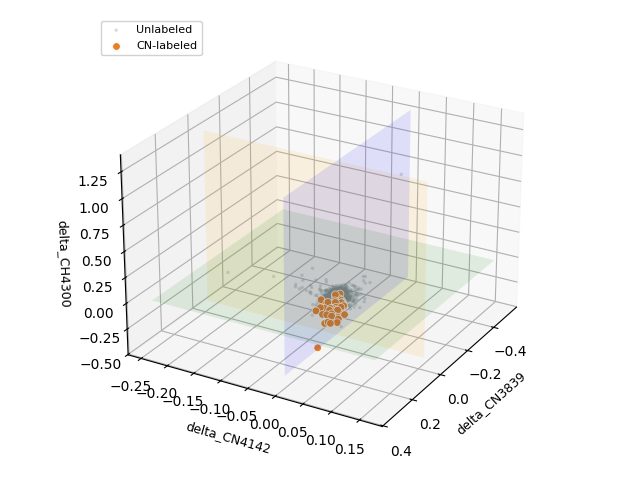

In [9]:
# 3D 散点图（delta特征）
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

plot_df = feature_df.copy()
cols_3d = ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'label']

plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=cols_3d).copy()

# 拆分标注/未标注样本
cn_df_plot = plot_df[plot_df['label'] == 1].copy()    # CN星（标注）
unl_df_plot = plot_df[plot_df['label'] == -1].copy()  # 未标注

# 未标注样本抽样
max_unlabeled_plot = 3000
if len(unl_df_plot) > max_unlabeled_plot:
    unl_df_plot = unl_df_plot.sample(max_unlabeled_plot, random_state=42)

plt.rcParams['font.size'] = 10  
fig = plt.figure()  
ax = fig.add_subplot(111, projection='3d')


x_min, x_max = plot_df['delta_CN3839'].min(), plot_df['delta_CN3839'].max()
y_min, y_max = plot_df['delta_CN4142'].min(), plot_df['delta_CN4142'].max()
z_min, z_max = plot_df['delta_CH4300'].min(), plot_df['delta_CH4300'].max()
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
y_grid2, z_grid2 = np.meshgrid(np.linspace(y_min, y_max, 10), np.linspace(z_min, z_max, 10))
x_grid3, z_grid3 = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(z_min, z_max, 10))

# 1. 水平面：z=0（垂直z轴）
ax.plot_surface(x_grid, y_grid, np.zeros_like(x_grid), 
                color='green', alpha=0.1, shade=False, zorder=0)
# 2. 垂直x轴平面：x=0
ax.plot_surface(np.zeros_like(y_grid2), y_grid2, z_grid2, 
                color='orange', alpha=0.1, shade=False, zorder=0)
# 3. 垂直y轴平面：y=0
ax.plot_surface(x_grid3, np.zeros_like(z_grid3), z_grid3, 
                color='blue', alpha=0.1, shade=False, zorder=0)

# 绘制散点图
# 未标注样本
ax.scatter(
    unl_df_plot['delta_CN3839'],
    unl_df_plot['delta_CN4142'],
    unl_df_plot['delta_CH4300'],
    c='#7f8c8d', s=6, alpha=0.3, label='Unlabeled',
    edgecolors='none', zorder=2
)

# 已知CN星
ax.scatter(
    cn_df_plot['delta_CN3839'],
    cn_df_plot['delta_CN4142'],
    cn_df_plot['delta_CH4300'],
    c='#e67e22', s=30, alpha=0.98, label='CN-labeled',
    edgecolors='white', linewidth=0.5, zorder=3
)

ax.set_xlabel('delta_CN3839', fontsize=9)
ax.set_ylabel('delta_CN4142', fontsize=9)
ax.set_zlabel('delta_CH4300', fontsize=9)

ax.view_init(elev=25, azim=30)

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

In [10]:
feature_df.head()

,teff,logg,feh,label,snru,mag_ps_g,knn_center_euclid,knn_euclid_prob,knn_center_dist_z,knn_center_teff,...,knn_center_feh,CN3839,CN4142,CH4300,nb_med_CN3839,nb_med_CN4142,nb_med_CH4300,delta_CN3839,delta_CN4142,delta_CH4300
0,5118.04,2.522,-1.653,-1,12.60,-999.0000,0.641437,0.932210,4.013244,5176.125889,...,-1.456372,0.066475,0.047542,0.122759,0.042962,0.004837,0.114069,0.023513,0.042705,0.008691
1,4738.28,1.863,-1.116,-1,7.06,16.2941,0.132736,0.464735,-0.092054,4706.926833,...,-1.098833,0.145064,-0.002233,0.205574,0.139764,-0.003403,0.210313,0.005300,0.001170,-0.004739
2,4563.05,1.419,-1.233,-1,12.88,15.4476,0.655883,0.935128,4.129826,4659.098278,...,-1.073261,0.224761,0.010548,0.246448,0.288440,0.019489,0.243939,-0.063679,-0.008941,0.002509
3,4951.77,2.366,-0.955,-1,10.41,-999.0000,0.232985,0.690464,0.716973,4947.084389,...,-1.018406,0.106550,-0.001504,0.206890,0.095350,-0.003036,0.198461,0.011200,0.001531,0.008429
4,5228.72,2.547,-1.629,-1,29.41,-999.0000,0.634513,0.930662,3.957370,5123.697778,...,-1.473417,0.033754,0.022313,0.073538,0.025918,0.006376,0.135407,0.007836,0.015937,-0.061869


In [11]:
from sklearn.decomposition import PCA

# 设置主成分数量（可手动指定或按方差比例自动确定）
# 方式一：固定数量
n_components = 10

# # 方式二：保留95%方差（若想使用请取消注释下面两行并注释上一行）
# pca = PCA(n_components=0.95)
# X_pca = pca.fit_transform(X_clean)
# n_components = X_pca.shape[1]

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_clean)

# 将主成分得分添加为新的特征列
for i in range(n_components):
    feature_df[f'pca_{i+1}'] = X_pca[:, i]

print(f"PCA 解释方差累计占比: {pca.explained_variance_ratio_.sum():.3f}")

PCA 解释方差累计占比: 0.401


In [12]:
# 构建 PCA 特征列名列表（兼容未显式执行 PCA 参数单元）
if 'n_components' in globals():
    pca_cols = [f'pca_{i+1}' for i in range(n_components)]
else:
    pca_cols = [c for c in feature_df.columns if c.startswith('pca_')]

# KNN 中心差分特征（可解释）
if {'teff', 'knn_center_teff'}.issubset(feature_df.columns):
    feature_df['delta_teff_center'] = feature_df['teff'] - feature_df['knn_center_teff']
if {'logg', 'knn_center_logg'}.issubset(feature_df.columns):
    feature_df['delta_logg_center'] = feature_df['logg'] - feature_df['knn_center_logg']
if {'feh', 'knn_center_feh'}.issubset(feature_df.columns):
    feature_df['delta_feh_center'] = feature_df['feh'] - feature_df['knn_center_feh']

# 选取用于分类的特征
base_feature_cols = [
    'teff', 'logg', 'feh',
    'CN3839', 'CN4142', 'CH4300',
    'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
    'nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300',
    'knn_center_euclid',
    'delta_teff_center', 'delta_logg_center', 'delta_feh_center'
 ]
feature_cols = [c for c in (base_feature_cols + pca_cols) if c in feature_df.columns]

print(f'最终特征数: {len(feature_cols)}')
print(feature_cols)

最终特征数: 26
['teff', 'logg', 'feh', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300', 'knn_center_euclid', 'delta_teff_center', 'delta_logg_center', 'delta_feh_center', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


## Machine Learning Imports And Utilities


In [13]:
# 机器学习统一导入与公共函数
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_fscore_support
)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

def prepare_model_data(df_input, feature_cols, random_state=42, test_size=0.3):
    df_model_local = df_input.dropna(subset=feature_cols + ['label']).copy()
    X_all_local = df_model_local[feature_cols].values
    y_all_local = df_model_local['label'].map({1: 1, -1: 0}).values
    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_all_local, y_all_local, test_size=test_size, stratify=y_all_local, random_state=random_state
    )
    return df_model_local, X_train_local, X_test_local, y_train_local, y_test_local

def topk_metrics(y_true, y_score, topk_list):
    out = {}
    order = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
    total_pos = max(int((y_true == 1).sum()), 1)
    for k in topk_list:
        k_eff = min(k, len(y_sorted))
        y_top = y_sorted[:k_eff]
        out[f'precision@{k}'] = float(y_top.mean()) if k_eff > 0 else np.nan
        out[f'recall@{k}'] = float(y_top.sum() / total_pos)
    return out

def evaluate_binary_model(model_name, y_true, y_prob, threshold=0.5, topk_list=None):
    if topk_list is None:
        topk_list = [50, 100, 200]
    y_pred = (y_prob >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    metrics = {
        'model': model_name,
        'ROC_AUC': roc_auc_score(y_true, y_prob),
        'PR_AUC': average_precision_score(y_true, y_prob),
        'Precision': p,
        'Recall': r,
        'F1': f1,
    }
    metrics.update(topk_metrics(y_true, y_prob, topk_list))
    return metrics


def attach_stars_metadata(df_in, stars_df, cols=None):
    """按 filepath 或 uid 补齐元信息，避免候选表缺列。"""
    if cols is None:
        cols = ['filepath', 'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'snrg', 'mag_ps_g', 'neighbor_indices', 'knn_euclid_prob']

    df = df_in.copy()
    use_cols = [c for c in cols if c in stars_df.columns]
    if not use_cols:
        return df

    if ('filepath' in df.columns) and ('filepath' in stars_df.columns):
        map_df = stars_df[use_cols].drop_duplicates(subset=['filepath'])
        df = df.merge(map_df, on='filepath', how='left', suffixes=('', '_meta'))
    elif ('uid' in df.columns) and ('uid' in stars_df.columns):
        map_df = stars_df[use_cols].drop_duplicates(subset=['uid'])
        df = df.merge(map_df, on='uid', how='left', suffixes=('', '_meta'))

    for c in use_cols:
        c_meta = f'{c}_meta'
        if c_meta in df.columns and c not in df.columns:
            df[c] = df[c_meta]
        if c_meta in df.columns and c in df.columns:
            miss_mask = df[c].isna() if hasattr(df[c], 'isna') else pd.Series(np.zeros(len(df), dtype=bool), index=df.index)
            df.loc[miss_mask, c] = df.loc[miss_mask, c_meta]

    drop_cols = [f'{c}_meta' for c in use_cols if f'{c}_meta' in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df

## 多模型对比实验
使用与相同的特征集合，统一训练/评估以下模型：
- XGBoost
- Random Forest
- LightGBM
- CatBoost
- SVM (RBF)
- MLP
- Isolation Forest（正样本一类建模）

In [14]:
# 统一多模型训练与评估
HAS_XGB = True
HAS_LGBM = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
except Exception:
    HAS_LGBM = False


RANDOM_STATE = 42
TOPK_LIST = [50, 100, 200]

if 'feature_cols' not in globals():
    if 'n_components' in globals():
        pca_cols = [f'pca_{i+1}' for i in range(n_components)]
    else:
        pca_cols = [c for c in feature_df.columns if c.startswith('pca_')]
    feature_cols = [
        'teff', 'logg', 'feh', 'mag_ps_g',
        'CN3839', 'CN4142', 'CH4300',
        'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
        'nb_med_CN3839', 'nb_med_CN4142', 'nb_med_CH4300'
    ] + pca_cols

df_model, X_train, X_test, y_train, y_test = prepare_model_data(
    feature_df, feature_cols, random_state=RANDOM_STATE, test_size=0.2
 )

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positives: {int((y_train == 1).sum())}, Test positives: {int((y_test == 1).sum())}')

results = []


n_pos = max(int((y_train == 1).sum()), 1)
n_neg = max(int((y_train == 0).sum()), 1)
xgb_cmp = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=2, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=n_neg / n_pos,
        eval_metric='logloss', random_state=RANDOM_STATE
    )
xgb_cmp.fit(X_train, y_train)
xgb_prob = xgb_cmp.predict_proba(X_test)[:, 1]
results.append(evaluate_binary_model('XGBoost', y_test, xgb_prob, topk_list=TOPK_LIST))


rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
 )
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_binary_model('RandomForest', y_test, rf_prob, topk_list=TOPK_LIST))


lgbm = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
    )
lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
results.append(evaluate_binary_model('LightGBM', y_test, lgbm_prob, topk_list=TOPK_LIST))



svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE))
])
svm_clf.fit(X_train, y_train)
svm_prob = svm_clf.predict_proba(X_test)[:, 1]
results.append(evaluate_binary_model('SVM_RBF', y_test, svm_prob, topk_list=TOPK_LIST))

mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu', alpha=1e-4,
        learning_rate_init=1e-3, max_iter=300, early_stopping=True, random_state=RANDOM_STATE
    ))
])
mlp.fit(X_train, y_train)
mlp_prob = mlp.predict_proba(X_test)[:, 1]
results.append(evaluate_binary_model('MLP_baseline', y_test, mlp_prob, topk_list=TOPK_LIST))

X_train_pos = X_train[y_train == 1]
if len(X_train_pos) >= 20:
    scaler_if = StandardScaler()
    X_train_pos_scaled = scaler_if.fit_transform(X_train_pos)
    X_test_scaled = scaler_if.transform(X_test)
    iso = IsolationForest(n_estimators=400, contamination=0.1, random_state=RANDOM_STATE)
    iso.fit(X_train_pos_scaled)
    iso_score = iso.decision_function(X_test_scaled)
    iso_prob_like = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min() + 1e-12)
    results.append(evaluate_binary_model('IsolationForest_posOnly', y_test, iso_prob_like, topk_list=TOPK_LIST))
else:
    print('正样本过少，跳过 IsolationForest。')

result_df = pd.DataFrame(results).sort_values(by='PR_AUC', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
display(result_df)

Train: (26871, 26), Test: (6718, 26)
Train positives: 58, Test positives: 15
[LightGBM] [Info] Number of positive: 58, number of negative: 26813
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6623
[LightGBM] [Info] Number of data points in the train set: 26871, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002158 -> initscore=-6.136199
[LightGBM] [Info] Start training from score -6.136199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,model,ROC_AUC,PR_AUC,Precision,Recall,F1,precision@50,recall@50,precision@100,recall@100,precision@200,recall@200
0,RandomForest,0.994908,0.512040,1.000000,0.266667,0.421053,0.20,0.666667,0.13,0.866667,0.075,1.000000
1,MLP_baseline,0.965060,0.396177,0.800000,0.266667,0.400000,0.18,0.600000,0.11,0.733333,0.060,0.800000
2,LightGBM,0.984992,0.346444,0.666667,0.133333,0.222222,0.18,0.600000,0.10,0.666667,0.060,0.800000
3,XGBoost,0.980645,0.338585,0.428571,0.400000,0.413793,0.20,0.666667,0.10,0.666667,0.055,0.733333
4,SVM_RBF,0.976170,0.205977,1.000000,0.066667,0.125000,0.16,0.533333,0.11,0.733333,0.055,0.733333
5,IsolationForest_posOnly,0.790164,0.145414,0.002974,0.933333,0.005930,0.10,0.333333,0.07,0.466667,0.045,0.600000


## MLP 多轮训练

Best epoch: 76, best val PR-AUC: 0.3943
MLP multi-round test PR-AUC: 0.3381
MLP multi-round test ROC-AUC: 0.9079
MLP candidates after filter: 69


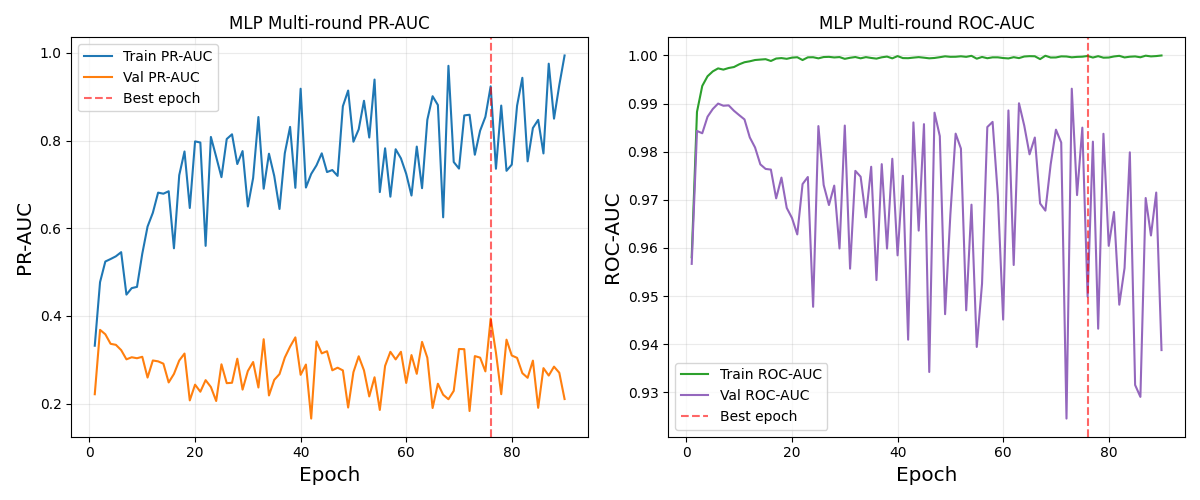

,ra,dec,teff,logg,feh,rv,snru,filepath,MLP_prob,CN_guided_term,final_score,delta_CN3839,delta_CN4142,CH4300,delta_CH4300
0,54.102908,72.785454,4320.22,1.005,-1.359,-373.22,12.31,dr13_new\spec-60258-LN032526N714105VB01_sp09-0...,0.999900,0.922650,0.982905,0.189820,0.010049,0.165188,-0.050984
1,170.934371,41.185576,4428.72,0.932,-1.744,-78.06,17.60,dr13_new\spec-60795-LN111354N395839VB01_sp12-1...,0.999848,0.912738,0.980684,0.075076,0.018272,0.180739,-0.035475
2,10.375679,39.955055,4515.82,0.927,-1.596,-209.99,19.74,dr13_new\spec-56582-VB012N41V1_sp02-186.fits.gz,0.999233,0.913185,0.980303,0.059567,0.009974,0.141440,-0.063408
3,247.988815,39.067282,4505.44,1.063,-1.400,-76.59,8.19,dr13_new\spec-58549-HD163804N393437V01_sp03-24...,0.999882,0.858915,0.968869,0.064045,0.016238,0.199879,-0.021868
4,69.680606,-2.744783,4440.98,1.183,-1.015,119.48,25.91,dr13_new\spec-60618-LN043339S014952VB01_sp06-1...,0.991032,0.878648,0.966307,0.089825,0.025042,0.200216,-0.023581
5,203.112046,34.644185,4912.44,1.911,-1.555,-63.86,36.97,dr13_new\spec-57035-HD133117N362849V01_sp01-12...,0.971448,0.945422,0.965723,0.160506,0.026080,0.168398,-0.030685
6,209.121820,-0.611698,4657.19,1.578,-1.465,-16.40,6.55,dr13_new\spec-56021-VB3_208S01_V1_sp09-113.fit...,0.989197,0.835192,0.955316,0.040662,0.007141,0.168373,-0.030859
7,267.024952,28.366495,4599.48,1.304,-1.656,-171.18,16.72,dr13_new\spec-60825-LN175745N291452VB01_sp10-2...,0.994343,0.814909,0.954868,0.021969,0.006079,0.164190,-0.051832
8,240.176256,7.722705,4642.62,1.491,-1.460,-52.01,33.78,dr13_new\spec-57852-HD160449N093841V01_sp02-01...,0.999285,0.782972,0.951696,0.047095,0.005616,0.191285,-0.012552
9,345.346046,27.985059,5217.78,2.873,-1.318,-106.14,38.55,dr13_new\spec-57652-HD230346N280458B01_sp04-16...,0.969319,0.863697,0.946082,0.074678,0.006530,0.115510,-0.040667


In [15]:
# MLP 多轮训练（MLP 概率 + CN 特征联合筛选）
import copy

RANDOM_STATE = 42
N_EPOCHS = 90
TOP_CANDIDATES = 400

def _rank01(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.rank(pct=True, method='average').fillna(0.0)

def add_cn_guided_score(df_in, prob_col='MLP_prob'):
    """基于 MLP 概率 + CN/CH 指标构造物理引导分数。"""
    out = df_in.copy()
    p = pd.to_numeric(out.get(prob_col, np.nan), errors='coerce').fillna(0.0).clip(0.0, 1.0)

    r_dcn3839 = _rank01(out['delta_CN3839']) if 'delta_CN3839' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_dcn4142 = _rank01(out['delta_CN4142']) if 'delta_CN4142' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_cn3839 = _rank01(out['CN3839']) if 'CN3839' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_cn4142 = _rank01(out['CN4142']) if 'CN4142' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)

    # CH 作为弱惩罚项，防止 CH 主导的假阳性
    r_ch4300 = _rank01(out['CH4300']) if 'CH4300' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_dch4300 = _rank01(out['delta_CH4300']) if 'delta_CH4300' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)

    cn_term = 0.40 * r_dcn3839 + 0.30 * r_dcn4142 + 0.20 * r_cn3839 + 0.10 * r_cn4142
    ch_penalty = 0.60 * r_ch4300 + 0.40 * r_dch4300
    physics_term = (cn_term - 0.30 * ch_penalty).clip(0.0, 1.0)

    out['CN_guided_term'] = physics_term.values
    out['final_score'] = (0.78 * p + 0.22 * physics_term).clip(0.0, 1.0).values
    return out

def run_mlp_multiround(df_input, feat_cols, random_state=42, n_epochs=90, top_candidates=400):
    df_model_local, X_train_full, X_test_full, y_train_full, y_test_full = prepare_model_data(
        df_input, feat_cols, random_state=random_state, test_size=0.2
    )
    X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
        X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_mlp_s = scaler.fit_transform(X_train_mlp)
    X_val_mlp_s = scaler.transform(X_val_mlp)
    X_test_mlp_s = scaler.transform(X_test_full)

    model = MLPClassifier(
        hidden_layer_sizes=(192, 96, 48), activation='relu', solver='adam',
        alpha=8e-4, learning_rate_init=6e-4, batch_size=128, max_iter=1,
        warm_start=True, shuffle=True, random_state=random_state
    )

    history = []
    best_val_pr_local = -np.inf
    best_epoch_local = 0
    best_model_local = None

    for epoch in range(1, n_epochs + 1):
        model.fit(X_train_mlp_s, y_train_mlp)
        tr_prob = model.predict_proba(X_train_mlp_s)[:, 1]
        va_prob = model.predict_proba(X_val_mlp_s)[:, 1]

        history.append({
            'epoch': epoch,
            'train_pr_auc': average_precision_score(y_train_mlp, tr_prob),
            'val_pr_auc': average_precision_score(y_val_mlp, va_prob),
            'train_roc_auc': roc_auc_score(y_train_mlp, tr_prob),
            'val_roc_auc': roc_auc_score(y_val_mlp, va_prob),
            'loss': float(getattr(model, 'loss_', np.nan))
        })

        if history[-1]['val_pr_auc'] > best_val_pr_local:
            best_val_pr_local = history[-1]['val_pr_auc']
            best_epoch_local = epoch
            best_model_local = copy.deepcopy(model)

    history_df_local = pd.DataFrame(history)
    test_prob = best_model_local.predict_proba(X_test_mlp_s)[:, 1]

    unlabeled_df_local = df_model_local[df_model_local['label'] == -1].copy()
    X_unlabeled = unlabeled_df_local[feat_cols].values
    unlabeled_df_local['MLP_prob'] = best_model_local.predict_proba(scaler.transform(X_unlabeled))[:, 1]

    if 'stars_clean' in globals():
        unlabeled_df_local = attach_stars_metadata(unlabeled_df_local, stars_clean)

    # MLP + CN 联合分数
    unlabeled_df_local = add_cn_guided_score(unlabeled_df_local, prob_col='MLP_prob')

    # 轻量筛选：去掉尾部低置信样本
    p = pd.to_numeric(unlabeled_df_local['MLP_prob'], errors='coerce').fillna(0.0)
    f = pd.to_numeric(unlabeled_df_local['final_score'], errors='coerce').fillna(0.0)
    p_thr = float(max(0.55, np.nanquantile(p, 0.70)))
    f_thr = float(max(0.60, np.nanquantile(f, 0.70)))
    keep_mask = (p >= p_thr) | (f >= f_thr)
    candidates_df_local = unlabeled_df_local.loc[keep_mask].copy()
    candidates_df_local = candidates_df_local.sort_values('final_score', ascending=False).reset_index(drop=True)

    return {
        'history_df': history_df_local,
        'best_epoch': best_epoch_local,
        'best_val_pr': best_val_pr_local,
        'test_pr_auc': average_precision_score(y_test_full, test_prob),
        'test_roc_auc': roc_auc_score(y_test_full, test_prob),
        'best_model': best_model_local,
        'scaler': scaler,
        'candidates_df': candidates_df_local,
        'candidates_top': candidates_df_local.head(top_candidates).copy()
    }

df_model = feature_df.copy()
if 'stars_clean' in globals() and len(stars_clean) == len(df_model):
    for col in [
        'filepath', 'uid', 'ra', 'dec', 'rv', 'snru',
        'neighbor_indices', 'knn_euclid_prob', 'knn_center_euclid'
    ]:
        if (col not in df_model.columns) and (col in stars_clean.columns):
            df_model[col] = stars_clean[col].values

mlp_run = run_mlp_multiround(df_model, feature_cols, RANDOM_STATE, N_EPOCHS, TOP_CANDIDATES)
history_df = mlp_run['history_df']
best_epoch = mlp_run['best_epoch']
best_val_pr = mlp_run['best_val_pr']
test_pr_auc = mlp_run['test_pr_auc']
test_roc_auc = mlp_run['test_roc_auc']
best_model = mlp_run['best_model']
scaler_mlp = mlp_run['scaler']
mlp_candidates_df = mlp_run['candidates_df']
mlp_candidates_top = mlp_run['candidates_top']

print(f'Best epoch: {best_epoch}, best val PR-AUC: {best_val_pr:.4f}')
print(f'MLP multi-round test PR-AUC: {test_pr_auc:.4f}')
print(f'MLP multi-round test ROC-AUC: {test_roc_auc:.4f}')
print(f'MLP candidates after filter: {len(mlp_candidates_df)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_df['epoch'], history_df['train_pr_auc'], label='Train PR-AUC', color='tab:blue')
axes[0].plot(history_df['epoch'], history_df['val_pr_auc'], label='Val PR-AUC', color='tab:orange')
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label='Best epoch')
axes[0].set_title('MLP Multi-round PR-AUC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('PR-AUC')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_roc_auc'], label='Train ROC-AUC', color='tab:green')
axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], label='Val ROC-AUC', color='tab:purple')
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label='Best epoch')
axes[1].set_title('MLP Multi-round ROC-AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

export_cols = [
    'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru',
    'filepath', 'MLP_prob', 'CN_guided_term', 'final_score',
    'delta_CN3839', 'delta_CN4142', 'CH4300', 'delta_CH4300'
 ]
export_cols = [c for c in export_cols if c in mlp_candidates_df.columns]
display(mlp_candidates_df[export_cols].head(10))

## 可视化候选

[MLP] 候选总数: 26


,filepath,teff,logg,feh,delta_CN3839,delta_CN4142,delta_CH4300,MLP_prob,CN_guided_term,final_score
0,dr13_new\spec-60258-LN032526N714105VB01_sp09-0...,4320.22,1.005,-1.359,0.189820,0.010049,-0.050984,0.999900,0.743768,0.943551
1,dr13_new\spec-57035-HD133117N362849V01_sp01-12...,4912.44,1.911,-1.555,0.160506,0.026080,-0.030685,0.971448,0.759710,0.924866
2,dr13_new\spec-57887-HD131404S024825V02_sp09-17...,4949.71,2.292,-1.353,0.153154,0.033629,-0.001028,0.976083,0.703188,0.916046
3,dr13_new\spec-60795-LN111354N395839VB01_sp12-1...,4428.72,0.932,-1.744,0.075076,0.018272,-0.035475,0.999848,0.584638,0.908502
4,dr13_new\spec-60618-LN043339S014952VB01_sp06-1...,4440.98,1.183,-1.015,0.089825,0.025042,-0.023581,0.991032,0.602899,0.905642
5,dr13_new\spec-56776-HD161834N071537V_sp04-091....,4505.44,1.516,-1.060,0.091023,0.027061,0.015927,0.999142,0.557681,0.902020
6,dr13_new\spec-56582-VB012N41V1_sp02-186.fits.gz,4515.82,0.927,-1.596,0.059567,0.009974,-0.063408,0.999233,0.515652,0.892845
7,dr13_new\spec-60408-LN145331N195318BM01_sp04-0...,4443.42,0.764,-1.701,0.128298,-0.002993,-0.068407,0.999829,0.484058,0.886360
8,dr13_new\spec-58549-HD163804N393437V01_sp03-24...,4505.44,1.063,-1.400,0.064045,0.016238,-0.021868,0.999882,0.478551,0.885189
9,dr13_new\spec-59942-HD020840N420946B03_sp07-15...,4730.11,1.410,-1.118,0.049915,0.025336,0.003469,0.990174,0.455652,0.872579


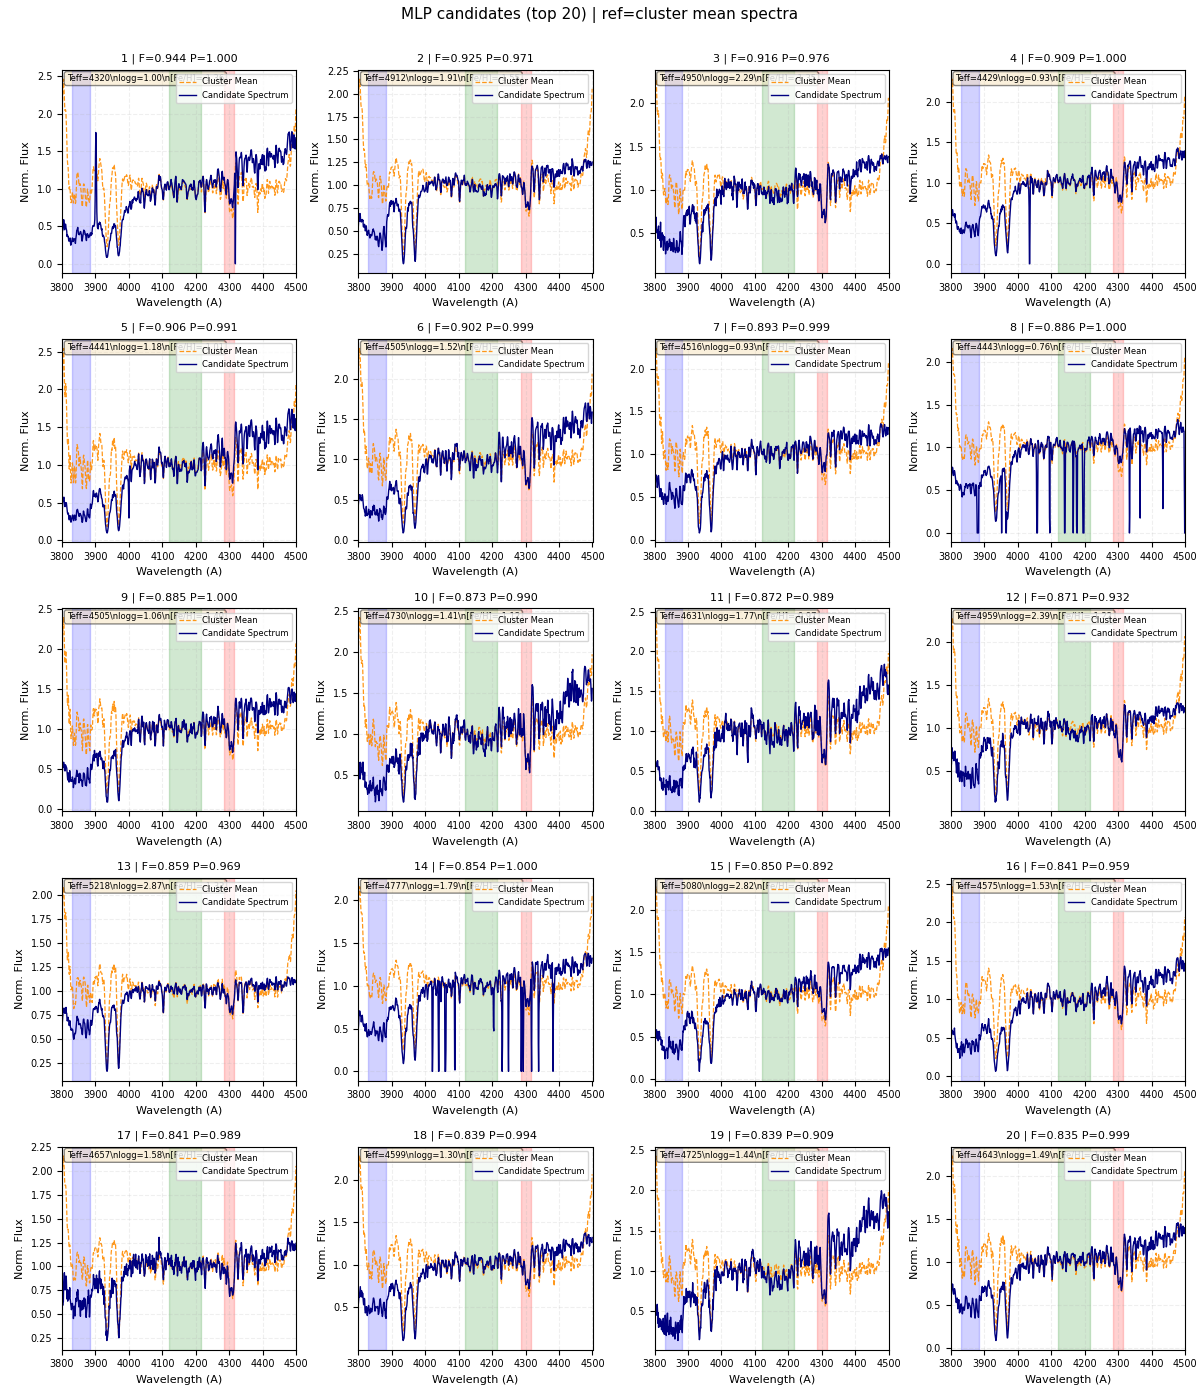

In [16]:
# 单模型候选可视化（基于 MLP + CN 联合筛选结果）
COMMON_EXPORT_TOP = 20
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if 'common_wave' not in globals():
    common_wave = np.arange(3800.0, 4500.0, 1.0)
if 'stars_clean' not in globals():
    raise RuntimeError('缺少 stars_clean，请先执行数据清洗与KNN单元。')
if 'X_clean' not in globals():
    raise RuntimeError('缺少 X_clean，请先执行光谱预处理单元。')
if len(X_clean) != len(stars_clean):
    raise RuntimeError('X_clean 与 stars_clean 行数不一致，无法构建聚类平均参考光谱。')
if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id，请先运行第6单元（KNN聚类单元）。')

c = 300000

def _pick_existing(df, cols):
    return [c0 for c0 in cols if c0 in df.columns]

def _rank01(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.rank(pct=True, method='average').fillna(0.0)

def add_cn_guided_score(df_in, prob_col='MLP_prob'):
    out = df_in.copy()
    p = pd.to_numeric(out.get(prob_col, np.nan), errors='coerce').fillna(0.0).clip(0.0, 1.0)

    r_dcn3839 = _rank01(out['delta_CN3839']) if 'delta_CN3839' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_dcn4142 = _rank01(out['delta_CN4142']) if 'delta_CN4142' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_cn3839 = _rank01(out['CN3839']) if 'CN3839' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_cn4142 = _rank01(out['CN4142']) if 'CN4142' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_ch4300 = _rank01(out['CH4300']) if 'CH4300' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    r_dch4300 = _rank01(out['delta_CH4300']) if 'delta_CH4300' in out.columns else pd.Series(np.zeros(len(out)), index=out.index)

    cn_term = 0.40 * r_dcn3839 + 0.30 * r_dcn4142 + 0.20 * r_cn3839 + 0.10 * r_cn4142
    ch_penalty = 0.60 * r_ch4300 + 0.40 * r_dch4300
    physics_term = (cn_term - 0.30 * ch_penalty).clip(0.0, 1.0)

    out['CN_guided_term'] = physics_term.values
    out['final_score'] = (0.78 * p + 0.22 * physics_term).clip(0.0, 1.0).values
    return out

def refine_candidate_ranking(cand_df, prob_col):
    out = add_cn_guided_score(cand_df, prob_col=prob_col)
    p = pd.to_numeric(out[prob_col], errors='coerce').fillna(0.0) if prob_col in out.columns else pd.Series(np.zeros(len(out)), index=out.index)
    f = pd.to_numeric(out['final_score'], errors='coerce').fillna(0.0)
    p_thr = float(max(0.55, np.nanquantile(p, 0.70)))
    f_thr = float(max(0.60, np.nanquantile(f, 0.70)))
    keep = (p >= p_thr) | (f >= f_thr)
    out = out.loc[keep].copy()
    out = out.sort_values('final_score', ascending=False).reset_index(drop=True)
    return out

def read_spectrum_from_file(filepath, rv=0.0):
    try:
        if (not isinstance(filepath, str)) or (not os.path.exists(filepath)):
            return None
        with afits.open(filepath, memmap=False) as hdul:
            if len(hdul) < 2 or hdul[1].data is None or len(hdul[1].data) == 0:
                return None
            row_data = hdul[1].data[0]
            wave = np.asarray(row_data['WAVELENGTH'], dtype=float)
            flux = np.asarray(row_data['FLUX'], dtype=float)
    except Exception:
        return None

    wave_rest = wave / (1.0 + (rv if np.isfinite(rv) else 0.0) / c)
    mask = np.isfinite(wave_rest) & np.isfinite(flux)
    if np.sum(mask) < 20:
        return None
    wave_rest = wave_rest[mask]
    flux = flux[mask]

    order = np.argsort(wave_rest)
    wave_rest = wave_rest[order]
    flux = flux[order]
    wave_rest, unique_idx = np.unique(wave_rest, return_index=True)
    flux = flux[unique_idx]
    if len(wave_rest) < 20:
        return None

    flux_interp = np.interp(common_wave, wave_rest, flux)
    if 'smooth_rescale_array' in globals():
        return smooth_rescale_array(flux_interp, n_smooth=0, n_rescale=80, deg=3, gass_kernel=True)

    finite = np.isfinite(flux_interp)
    if not np.any(finite):
        return None
    med = np.median(flux_interp[finite])
    return flux_interp / med if np.isfinite(med) and med != 0 else flux_interp

# KNN 掩盖聚类标签作为参考聚类
cluster_ids = pd.to_numeric(stars_clean['masked_cluster_id'], errors='coerce')
valid_cluster_mask = np.isfinite(cluster_ids.values)
if not np.any(valid_cluster_mask):
    raise RuntimeError('masked_cluster_id 全部无效，无法构建参考光谱。')

cluster_ids_int = cluster_ids[valid_cluster_mask].astype(int).values
X_cluster_ref = X_clean[valid_cluster_mask]

cluster_mean_flux = {}
for cid in np.unique(cluster_ids_int):
    m = cluster_ids_int == cid
    if np.sum(m) == 0:
        continue
    cluster_mean_flux[int(cid)] = np.nanmean(X_cluster_ref[m], axis=0)

def plot_candidate_spectra(model_name, cand_df, prob_col, top_n=20):
    top = cand_df.head(top_n).copy()
    n_cols = 4
    n_rows = int(np.ceil(top_n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.8 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    fp_to_idx = {fp: i for i, fp in enumerate(stars_clean['filepath'])} if 'filepath' in stars_clean.columns else {}

    for i, (_, row) in enumerate(top.iterrows()):
        ax = axes[i]
        filepath = row['filepath'] if 'filepath' in row else None
        rv = row['rv'] if ('rv' in row and np.isfinite(row['rv'])) else 0.0
        norm_flux = read_spectrum_from_file(filepath, rv=rv)

        if norm_flux is None:
            ax.text(0.5, 0.5, 'Failed to read', ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(f'{model_name} #{i+1} (error)', fontsize=9)
            continue

        ax.axvspan(3830, 3883, alpha=0.18, color='blue', zorder=0)
        ax.axvspan(4120, 4216, alpha=0.18, color='green', zorder=0)
        ax.axvspan(4285, 4315, alpha=0.18, color='red', zorder=0)

        if filepath in fp_to_idx:
            cidx = fp_to_idx[filepath]
            cid = int(stars_clean.iloc[cidx]['masked_cluster_id']) if 'masked_cluster_id' in stars_clean.columns else None
            if cid is not None and cid in cluster_mean_flux:
                ref_flux = cluster_mean_flux[cid]
                ax.plot(common_wave, ref_flux, color='darkorange', linewidth=0.9, alpha=0.9, linestyle='--', zorder=1, label='Cluster Mean')

        ax.plot(common_wave, norm_flux, color='navy', linewidth=1.0, zorder=2, label='Candidate Spectrum')

        p_model = float(row[prob_col]) if (prob_col in row and np.isfinite(row[prob_col])) else np.nan
        p_final = float(row['final_score']) if ('final_score' in row and np.isfinite(row['final_score'])) else np.nan

        ax.set_xlim(3800, 4500)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlabel('Wavelength (A)', fontsize=8)
        ax.set_ylabel('Norm. Flux', fontsize=8)
        ax.set_title(f'{i+1} | F={p_final:.3f} P={p_model:.3f}', fontsize=8)

        if all(k in row for k in ['teff', 'logg', 'feh']) and np.isfinite(row.get('teff', np.nan)):
            textstr = f"Teff={row['teff']:.0f}\\nlogg={row['logg']:.2f}\\n[Fe/H]={row['feh']:.2f}"
            ax.text(
                0.02, 0.98, textstr, transform=ax.transAxes, fontsize=6,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.45), zorder=3
            )

        ax.grid(True, alpha=0.2, linestyle='--', zorder=0)
        ax.legend(loc='upper right', fontsize=6, framealpha=0.8)
    for j in range(len(top), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{model_name} candidates (top {top_n}) | ref=cluster mean spectra', fontsize=11, y=0.995)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

model_specs = [
    ('MLP', 'mlp_candidates_df', 'MLP_prob'),
]

for model_name, var_name, prob_col in model_specs:
    if var_name not in globals():
        print(f'[{model_name}] 跳过：{var_name} 不存在，请先运行对应模型单元。')
        continue

    cand_df = globals()[var_name].copy()
    cand_df = attach_stars_metadata(cand_df, stars_clean)
    cand_df = refine_candidate_ranking(cand_df, prob_col=prob_col)

    globals()[var_name] = cand_df

    print(f'[{model_name}] 候选总数: {len(cand_df)}')
    show_cols = [
        'filepath', 'teff', 'logg', 'feh',
        'delta_CN3839', 'delta_CN4142', 'delta_CH4300',
        prob_col, 'CN_guided_term', 'final_score'
    ]
    show_cols = _pick_existing(cand_df, show_cols)
    display(cand_df[show_cols].head(10))

    plot_candidate_spectra(model_name, cand_df, prob_col, top_n=COMMON_EXPORT_TOP)

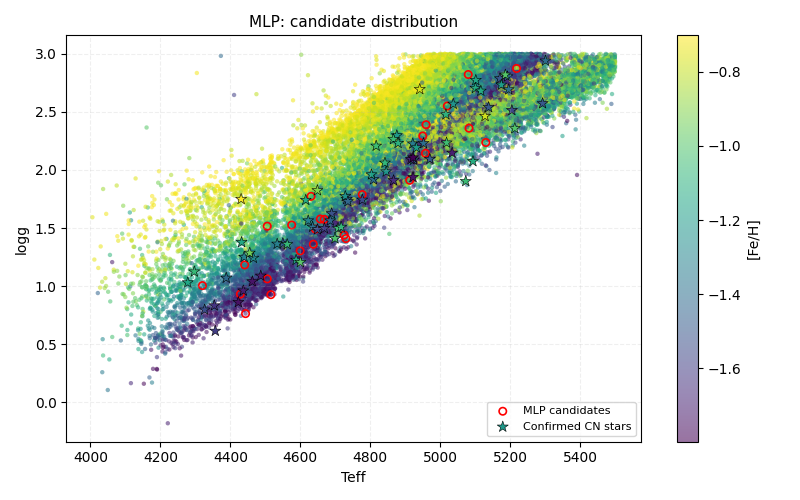

In [17]:
# 参数空间散点对比：模型圈选 + 已确认 CN 星对照

plot_cols = ['teff', 'logg', 'feh', 'filepath', 'label']
use_cols = [c for c in plot_cols if c in stars_clean.columns]
base = stars_clean[use_cols].copy()
base = base.dropna(subset=[c for c in ['teff', 'logg', 'feh'] if c in base.columns]).copy()

model_specs = [('MLP', 'mlp_candidates_df', 'MLP_prob')]

available_models = []
for name, var_name, prob_col in model_specs:
    if var_name in globals():
        available_models.append((name, var_name, prob_col))

if len(available_models) == 0:
    raise RuntimeError('未找到可视化候选表，请先运行 MLP 候选单元。')

fig, axes = plt.subplots(len(available_models), 1, figsize=(8, 5 * len(available_models)))
if len(available_models) == 1:
    axes = [axes]

for ax, (model_name, var_name, prob_col) in zip(axes, available_models):
    cand_df = globals()[var_name].copy()

    # 优先使用 final_score；若缺失则回退到 MLP_prob
    sort_col = 'final_score' if 'final_score' in cand_df.columns else prob_col
    cand_df = cand_df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    top = cand_df.head(1000).copy()

    sc = ax.scatter(
        base['teff'], base['logg'], c=base['feh'], cmap='viridis',
        s=10, alpha=0.55, edgecolors='none'
    )

    if 'filepath' in top.columns and 'filepath' in base.columns:
        top_map = top[['filepath', sort_col]].drop_duplicates().merge(
            base[['filepath', 'teff', 'logg', 'feh']], on='filepath', how='left'
        )
    else:
        merge_cols = [c for c in ['ra', 'dec', 'teff', 'logg', 'feh'] if c in top.columns and c in base.columns]
        if {'teff', 'logg', 'feh'}.issubset(merge_cols):
            top_map = top[merge_cols].copy()
        else:
            top_map = pd.DataFrame(columns=['teff', 'logg', 'feh'])

    top_map = top_map.dropna(subset=['teff', 'logg', 'feh']) if len(top_map) > 0 else top_map

    if len(top_map) > 0:
        ax.scatter(
            top_map['teff'], top_map['logg'],
            facecolors='none', edgecolors='red', s=28, linewidths=1.2,
            label=f'{model_name} candidates'
        )

    cn_confirmed = base[base['label'] == 1].copy() if 'label' in base.columns else pd.DataFrame()
    if len(cn_confirmed) > 0:
        ax.scatter(
            cn_confirmed['teff'], cn_confirmed['logg'], c=cn_confirmed['feh'], cmap='viridis',
            s=70, marker='*', edgecolors='black', linewidths=0.4, label='Confirmed CN stars'
        )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('[Fe/H]', fontsize=10)

    ax.set_xlabel('Teff', fontsize=10)
    ax.set_ylabel('logg', fontsize=10)
    ax.set_title(f'{model_name}: candidate distribution', fontsize=11)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

Rows after dropna: 33589
Feature count: 26
Train positives: 58
Train unlabeled pool: 26813
Test rows: 6718

=== MLP 自训练结果 ===
Best round: 1, best val PR-AUC: 0.9989
                      0
ROC_AUC        0.975046
PR_AUC         0.118135
Precision      0.054167
Recall         0.866667
F1             0.101961
precision@50   0.100000
recall@50      0.333333
precision@100  0.090000
recall@100     0.600000
precision@200  0.060000
recall@200     0.800000
precision@400  0.032500
recall@400     0.866667
Exported file: mlp_self_training_mul_20260429_222829.csv


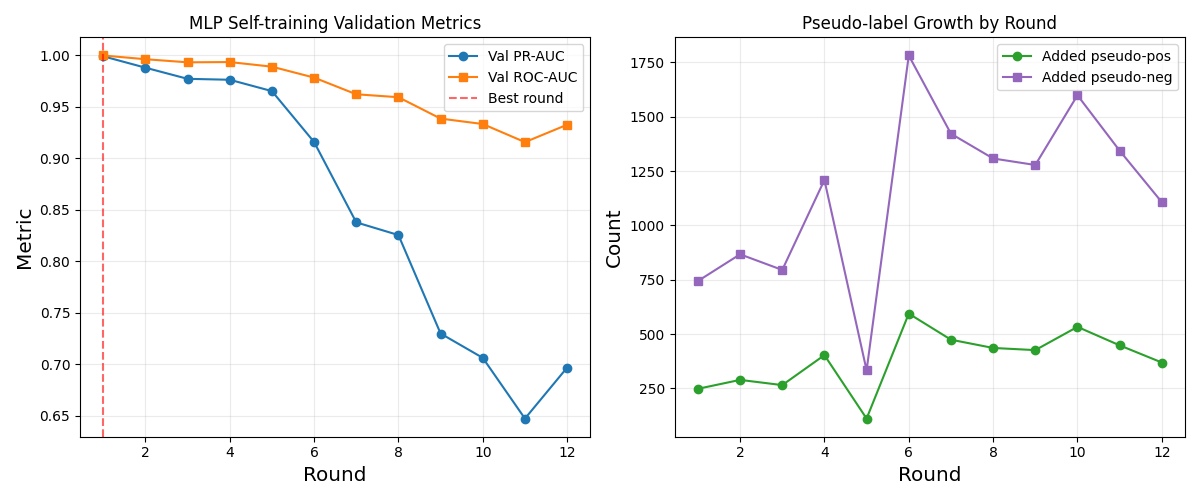

,ra,dec,teff,logg,feh,rv,filepath,MLP_ST_prob,KNN_phys_prob,explainable_score,CN3839,CN4142,CH4300,delta_CN3839,delta_CN4142,delta_CH4300
0,246.377710,39.249850,5313.74,2.673,-1.665,-31.91,dr13_new\spec-56043-B5604306_sp11-198.fits.gz,0.999925,0.999464,0.999764,-0.025972,-0.002284,0.060526,-0.059095,-0.005894,-0.058672
1,178.165868,12.229064,5226.80,2.796,-1.585,-64.90,dr13_new\spec-60681-LN115124N114818BM01_sp04-1...,0.999983,0.999107,0.999676,0.041025,0.022552,0.065729,0.008562,0.019024,-0.053468
2,163.659101,29.752188,5184.41,2.696,-1.629,-87.89,dr13_new\spec-55907-B90706_sp14-134.fits.gz,0.999955,0.998809,0.999554,-0.004572,-0.006970,0.058461,-0.037695,-0.010580,-0.060737
3,237.703453,36.114818,5283.18,2.821,-1.235,-267.21,dr13_new\spec-60821-LN155051N373312BM01_sp05-0...,0.999808,0.998333,0.999292,-0.008219,0.000648,0.112743,-0.042439,-0.003016,-0.007107
4,63.453630,49.631808,5425.73,2.962,-0.923,-14.65,dr13_new\spec-57326-HD042432N505042V01_sp02-18...,0.999206,0.999434,0.999286,0.025234,0.015033,0.088624,-0.007229,0.011456,-0.031226
5,10.375679,39.955055,4515.82,0.927,-1.596,-209.99,dr13_new\spec-56582-VB012N41V1_sp02-186.fits.gz,0.999870,0.998095,0.999249,0.212619,0.012686,0.141440,0.059567,0.009974,-0.063408
6,170.934371,41.185576,4428.72,0.932,-1.744,-78.06,dr13_new\spec-60795-LN111354N395839VB01_sp12-1...,0.999631,0.998511,0.999239,0.266955,0.022647,0.180739,0.075076,0.018272,-0.035475
7,200.122940,44.262850,4501.67,1.031,-1.663,-223.84,dr13_new\spec-56678-HD131249N423736V01_sp12-01...,0.999242,0.999047,0.999174,0.248135,0.020312,0.219570,0.048139,0.019897,-0.002096
8,226.373651,6.070976,5210.80,2.946,-1.240,-19.05,dr13_new\spec-60080-HD151331N050239B03_sp14-00...,0.999746,0.997946,0.999116,0.047455,0.012006,0.128301,0.014992,0.008429,0.009877
9,223.392462,19.470645,4443.42,0.764,-1.701,20.94,dr13_new\spec-60408-LN145331N195318BM01_sp04-0...,0.998935,0.998958,0.998943,0.274858,0.000085,0.130536,0.128298,-0.002993,-0.068407


In [18]:
# MLP 多轮自训练
# 说明：
# 1) 正类(1)视为可信标签，未标注(-1)分轮打伪标签；
# 2) 每轮使用高/低双阈值选伪正/伪负，动态放宽阈值；
# 3) 由于当前 sklearn 版本的 MLPClassifier.fit 不支持 sample_weight，
#    这里采用“正类上采样”来平衡训练；
# 4) 最终输出候选表（带时间戳，避免覆盖旧结果）和诊断图。

import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
)


def _prepare_model_data_local(df_input, feat_cols, random_state=42, test_size=0.2):
    """将标签映射为二分类：1->1, -1->0，并做分层切分。"""
    df_model_local = df_input.dropna(subset=feat_cols + ['label']).copy()
    X_all = df_model_local[feat_cols].values
    y_all = df_model_local['label'].map({1: 1, -1: 0}).values

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_all,
        y_all,
        test_size=test_size,
        stratify=y_all,
        random_state=random_state,
    )
    return df_model_local, X_train_local, X_test_local, y_train_local, y_test_local


def _evaluate_binary(y_true, y_prob, threshold=0.5, topk_list=None):
    """统一输出 ROC-AUC / PR-AUC / 阈值指标 / Top-k 指标。"""
    if topk_list is None:
        topk_list = [50, 100, 200, 400]

    y_pred = (y_prob >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    out = {
        'ROC_AUC': float(roc_auc_score(y_true, y_prob)),
        'PR_AUC': float(average_precision_score(y_true, y_prob)),
        'Precision': float(p),
        'Recall': float(r),
        'F1': float(f1),
    }

    order = np.argsort(y_prob)[::-1]
    y_sorted = y_true[order]
    total_pos = max(int((y_true == 1).sum()), 1)
    for k in topk_list:
        k_eff = min(k, len(y_sorted))
        y_top = y_sorted[:k_eff]
        out[f'precision@{k}'] = float(y_top.mean()) if k_eff > 0 else np.nan
        out[f'recall@{k}'] = float(y_top.sum() / total_pos)
    return out


def _attach_meta_and_score(df_candidates, alpha=0.65):
    """补元信息并融合 KNN 物理可解释概率。"""
    out = df_candidates.copy()

    # 尝试补齐元数据
    if 'stars_clean' in globals():
        for c in ['filepath', 'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'snrg', 'mag_ps_g', 'knn_euclid_prob']:
            if (c not in out.columns) and (c in stars_clean.columns) and (len(stars_clean) == len(feature_df)):
                # 按索引对齐赋值，仅在行数一致时启用
                out[c] = stars_clean.loc[out.index, c].values

    model_prob = pd.to_numeric(out['MLP_ST_prob'], errors='coerce').fillna(0.0).clip(0.0, 1.0)
    if 'knn_euclid_prob' in out.columns:
        knn_prob = pd.to_numeric(out['knn_euclid_prob'], errors='coerce')
        med = np.nanmedian(knn_prob.values)
        fill_v = med if np.isfinite(med) else 0.5
        knn_prob = knn_prob.fillna(fill_v).clip(0.0, 1.0)
    else:
        knn_prob = pd.Series(np.full(len(out), 0.5), index=out.index)

    out['KNN_phys_prob'] = knn_prob.values
    out['explainable_score'] = alpha * model_prob.values + (1.0 - alpha) * knn_prob.values
    out = out.sort_values('explainable_score', ascending=False).reset_index(drop=True)
    return out


def run_mlp_self_training_multiround_v2(
    df_input,
    feat_cols,
    random_state=42,
    test_size=0.2,
    max_rounds=12,
    max_iter_per_fit=220,
    high_start=0.98,
    high_end=0.90,
    low_start=0.02,
    low_end=0.10,
    add_rate=0.04,
    min_add_each=20,
    neg_pos_cap=3.0,
    alpha_explain=0.65,
    top_candidates=400,
):
    """
    多轮自训练核心流程。
    - 正样本集合固定为真实正类 + 历轮伪正
    - 负样本集合来自初始化伪负 + 历轮伪负
    - 每轮训练后，对未使用的未标注样本按高/低阈值增量打伪标签
    """
    df_model_local, X_train, X_test, y_train, y_test = _prepare_model_data_local(
        df_input, feat_cols, random_state=random_state, test_size=test_size
    )

    pos_idx = np.where(y_train == 1)[0]
    unl_idx = np.where(y_train == 0)[0]

    print(f'Rows after dropna: {len(df_model_local)}')
    print(f'Feature count: {len(feat_cols)}')
    print(f'Train positives: {len(pos_idx)}')
    print(f'Train unlabeled pool: {len(unl_idx)}')
    print(f'Test rows: {len(y_test)}')

    if len(pos_idx) < 8 or len(unl_idx) < 30:
        raise RuntimeError('正样本或未标注样本过少，无法稳定进行自训练。')

    rng = np.random.RandomState(random_state)

    # 初始化伪负：从未标注中随机抽一批，避免模型第一轮完全失衡
    init_neg_n = min(max(3 * len(pos_idx), 300), len(unl_idx))
    pseudo_neg = set(rng.choice(unl_idx, size=init_neg_n, replace=False).tolist())
    pseudo_pos = set()

    # 留一批未标注作为“轮内验证负类代理”，监控过拟合和确认偏差
    holdout_unl_n = min(max(2 * len(pos_idx), 200), len(unl_idx))
    holdout_unl = set(rng.choice(unl_idx, size=holdout_unl_n, replace=False).tolist())
    remain_unl_for_iter = set(unl_idx.tolist()) - holdout_unl

    history = []
    best_val_pr = -np.inf
    best_state = None
    stagnant_rounds = 0

    for rd in range(1, max_rounds + 1):
        # 阈值按轮次逐渐放宽：前期更保守，后期适当扩张
        frac = (rd - 1) / max(max_rounds - 1, 1)
        high_th = high_start + frac * (high_end - high_start)
        low_th = low_start + frac * (low_end - low_start)

        train_idx = np.array(sorted(set(pos_idx.tolist()) | pseudo_pos | pseudo_neg), dtype=int)
        y_train_iter = np.zeros(len(train_idx), dtype=int)
        y_train_iter[np.isin(train_idx, pos_idx)] = 1
        if len(pseudo_pos) > 0:
            y_train_iter[np.isin(train_idx, list(pseudo_pos))] = 1

        # 采用正类上采样而不是 sample_weight
        pos_mask = (y_train_iter == 1)
        neg_mask = (y_train_iter == 0)

        X_pos, y_pos = X_train[train_idx][pos_mask], y_train_iter[pos_mask]
        X_neg, y_neg = X_train[train_idx][neg_mask], y_train_iter[neg_mask]

        n_pos_iter = len(y_pos)
        n_neg_iter = len(y_neg)
        if n_pos_iter == 0 or n_neg_iter == 0:
            break

        up_factor = max(1, int(np.ceil(n_neg_iter / max(n_pos_iter, 1))))
        X_pos_up = np.repeat(X_pos, up_factor, axis=0)
        y_pos_up = np.repeat(y_pos, up_factor, axis=0)

        X_bal = np.vstack([X_neg, X_pos_up])
        y_bal = np.concatenate([y_neg, y_pos_up])

        perm = rng.permutation(len(y_bal))
        X_bal = X_bal[perm]
        y_bal = y_bal[perm]

        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(192, 96, 48),
                activation='relu',
                solver='adam',
                alpha=8e-4,
                learning_rate_init=6e-4,
                batch_size=128,
                max_iter=max_iter_per_fit,
                early_stopping=True,
                n_iter_no_change=20,
                validation_fraction=0.15,
                random_state=random_state + rd,
            ))
        ])
        clf.fit(X_bal, y_bal)

        # 轮内验证：真实正类 vs 留出的未标注代理负类
        val_idx = np.array(sorted(set(pos_idx.tolist()) | holdout_unl), dtype=int)
        y_val = np.isin(val_idx, pos_idx).astype(int)
        val_prob = clf.predict_proba(X_train[val_idx])[:, 1]
        val_pr = average_precision_score(y_val, val_prob)
        val_roc = roc_auc_score(y_val, val_prob)

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = (clf, rd)

        remaining = np.array(sorted(remain_unl_for_iter - pseudo_pos - pseudo_neg), dtype=int)
        if len(remaining) == 0:
            history.append({
                'round': rd,
                'high_th': high_th,
                'low_th': low_th,
                'n_train': len(train_idx),
                'n_pos_train': n_pos_iter,
                'n_neg_train': n_neg_iter,
                'add_pos': 0,
                'add_neg': 0,
                'remain_unl': 0,
                'val_pr_auc': val_pr,
                'val_roc_auc': val_roc,
            })
            break

        remain_prob = clf.predict_proba(X_train[remaining])[:, 1]

        # 每轮新增量设上限，防止确认偏差快速滚大
        add_cap = max(min_add_each, int(add_rate * len(remaining)))

        high_mask = remain_prob >= high_th
        low_mask = remain_prob <= low_th
        cand_pos = remaining[high_mask]
        cand_neg = remaining[low_mask]

        if len(cand_pos) > add_cap:
            order = np.argsort(remain_prob[high_mask])[::-1]
            cand_pos = cand_pos[order[:add_cap]]

        neg_cap = int(max(1, neg_pos_cap * max(len(cand_pos), 1)))
        if len(cand_neg) > neg_cap:
            order = np.argsort(remain_prob[low_mask])
            cand_neg = cand_neg[order[:neg_cap]]

        prev_total = len(pseudo_pos) + len(pseudo_neg)
        pseudo_pos.update(cand_pos.tolist())
        pseudo_neg.update(cand_neg.tolist())
        added = (len(pseudo_pos) + len(pseudo_neg)) - prev_total

        history.append({
            'round': rd,
            'high_th': high_th,
            'low_th': low_th,
            'n_train': len(train_idx),
            'n_pos_train': n_pos_iter,
            'n_neg_train': n_neg_iter,
            'add_pos': int(len(cand_pos)),
            'add_neg': int(len(cand_neg)),
            'remain_unl': int(len(remaining)),
            'val_pr_auc': float(val_pr),
            'val_roc_auc': float(val_roc),
        })

        # 连续两轮无新增则提前停止
        if added == 0:
            stagnant_rounds += 1
        else:
            stagnant_rounds = 0
        if stagnant_rounds >= 2:
            break

    if best_state is None:
        raise RuntimeError('自训练未得到有效模型，请检查特征和标签分布。')

    best_model, best_round = best_state
    test_prob = best_model.predict_proba(X_test)[:, 1]
    eval_dict = _evaluate_binary(y_test, test_prob, threshold=0.5, topk_list=[50, 100, 200, 400])

    # 对全体未标注池打分并导出候选
    unlabeled_df = df_model_local[df_model_local['label'] == -1].copy()
    X_unl = unlabeled_df[feat_cols].values
    unlabeled_df['MLP_ST_prob'] = best_model.predict_proba(X_unl)[:, 1]
    unlabeled_df = _attach_meta_and_score(unlabeled_df, alpha=alpha_explain)

    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_file = f'mlp_self_training_mul_{ts}.csv'
    unlabeled_df.to_csv(out_file, index=False)

    return {
        'history_df': pd.DataFrame(history),
        'best_round': int(best_round),
        'best_val_pr': float(best_val_pr),
        'eval': eval_dict,
        'candidates_df': unlabeled_df,
        'candidates_top': unlabeled_df.head(top_candidates).copy(),
        'export_file': out_file,
    }

if 'feature_df' not in globals() or 'feature_cols' not in globals():
    raise RuntimeError('缺少 feature_df 或 feature_cols。请先运行前面的特征工程单元。')

if 'label' not in feature_df.columns:
    raise RuntimeError('feature_df 中缺少 label 列，无法进行自训练。')

df_model_mlp_st = feature_df.copy()

# 尽可能补充元数据列，便于后续导出和交叉匹配
if 'stars_clean' in globals() and len(stars_clean) == len(df_model_mlp_st):
    for col in [
        'filepath', 'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'snrg', 'mag_ps_g',
        'neighbor_indices', 'knn_euclid_prob', 'knn_center_euclid', 'knn_center_dist_z'
    ]:
        if (col not in df_model_mlp_st.columns) and (col in stars_clean.columns):
            df_model_mlp_st[col] = stars_clean[col].values

mlp_st_run = run_mlp_self_training_multiround_v2(
    df_model_mlp_st,
    feature_cols,
    random_state=42,
    test_size=0.2,
    max_rounds=12,
    max_iter_per_fit=220,
    high_start=0.98,
    high_end=0.90,
    low_start=0.02,
    low_end=0.10,
    add_rate=0.04,
    min_add_each=20,
    neg_pos_cap=3.0,
    alpha_explain=0.65,
    top_candidates=400,
)

history_df = mlp_st_run['history_df']
print('\n=== MLP 自训练结果 ===')
print(f"Best round: {mlp_st_run['best_round']}, best val PR-AUC: {mlp_st_run['best_val_pr']:.4f}")
print(pd.DataFrame([mlp_st_run['eval']]).T)
print(f"Exported file: {mlp_st_run['export_file']}")

# 诊断图1：验证指标随轮次变化
# 诊断图2：每轮新增伪标签数量
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_df['round'], history_df['val_pr_auc'], marker='o', color='tab:blue', label='Val PR-AUC')
axes[0].plot(history_df['round'], history_df['val_roc_auc'], marker='s', color='tab:orange', label='Val ROC-AUC')
axes[0].axvline(mlp_st_run['best_round'], color='red', linestyle='--', alpha=0.6, label='Best round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Metric')
axes[0].set_title('MLP Self-training Validation Metrics')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df['round'], history_df['add_pos'], marker='o', color='tab:green', label='Added pseudo-pos')
axes[1].plot(history_df['round'], history_df['add_neg'], marker='s', color='tab:purple', label='Added pseudo-neg')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Count')
axes[1].set_title('Pseudo-label Growth by Round')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# 预览候选表头部
show_cols = [
    'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'filepath',
    'MLP_ST_prob', 'KNN_phys_prob', 'explainable_score',
    'CN3839', 'CN4142', 'CH4300',
    'delta_CN3839', 'delta_CN4142', 'delta_CH4300'
]
show_cols = [c for c in show_cols if c in mlp_st_run['candidates_df'].columns]
display(mlp_st_run['candidates_df'][show_cols].head(10))